### **Import Library**

Pada bagian ini dilakukan import library yang dibutuhkan selama proses analisis data dan pembuatan model machine learning. Library seperti pandas digunakan untuk mengolah data, numpy untuk operasi numerik, matplotlib dan seaborn untuk visualisasi data, serta sklearn untuk proses preprocessing, pembagian data, pelatihan model, dan evaluasi model.

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### **Load Dataset**

Section ini digunakan untuk memuat dataset training dan testing ke dalam program menggunakan pandas.read_csv(). Dataset kemudian disimpan ke dalam variabel agar dapat digunakan pada tahap analisis berikutnya.

Tujuan:
1. Membaca file dataset.
2. Menampilkan isi data awal.
3. Memastikan data berhasil dimuat.

In [24]:
import pandas as pd
data_training=pd.read_csv('/content/data_training.csv')
data_training

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


In [25]:
import pandas as pd
data_testing=pd.read_csv('/content/data_testing.csv')
data_testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.610,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.840,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.580,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.480,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.600,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516
...,...,...,...,...,...,...,...,...,...,...,...,...
281,10.0,0.410,0.45,6.2,0.071,6.0,14.0,0.99702,3.21,0.49,11.800000,1147
282,10.6,0.830,0.37,2.6,0.086,26.0,70.0,0.99810,3.16,0.52,9.900000,296
283,7.9,0.885,0.03,1.8,0.058,4.0,8.0,0.99720,3.36,0.33,9.100000,170
284,7.3,0.670,0.02,2.2,0.072,31.0,92.0,0.99566,3.32,0.68,11.066667,1439


### **Eksplorasi Data**

Tahap eksplorasi data dilakukan untuk memahami karakteristik dataset sebelum dilakukan pemodelan.

Pada bagian ini dilakukan:
1. Melihat informasi dataset dengan info().
2. Mengecek jumlah data kosong (missing value).
3. Mengecek tipe data.
4. Melihat statistik deskriptif data.

Tujuan:
1. Mengetahui kondisi dataset.
2. Menentukan langkah preprocessing yang diperlukan.

In [26]:
print(data_training.info())
print(data_training.describe())
print(data_training.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
co

In [27]:
data_training.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [28]:
data_testing.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### **Grafik/Visualisasi Data**

Pada section ini dilakukan visualisasi data menggunakan grafik untuk membantu memahami distribusi data dan hubungan antar variabel.

Visualisasi yang dilakukan antara lain:
1. Grafik distribusi kualitas (quality).
2. Heatmap korelasi.
3. Grafik fitur terhadap target.

Tujuan:
1. Mempermudah analisis pola data.
2. Mengetahui hubungan antar fitur.
3. Membantu memahami persebaran data.

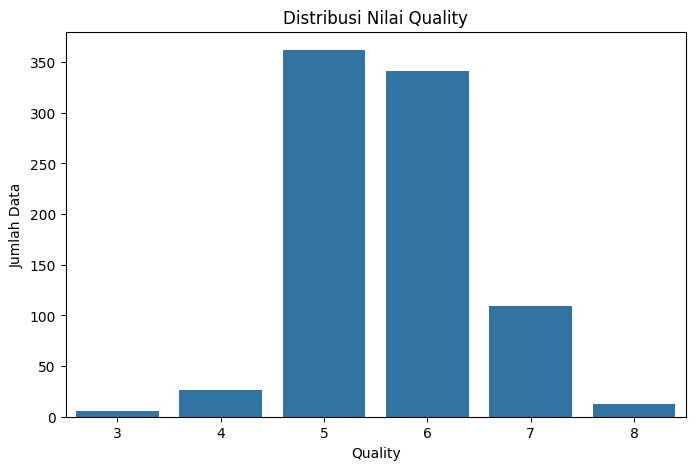

In [29]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=data_training)
plt.title('Distribusi Nilai Quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')
plt.show()

In [30]:
print("Jumlah data duplikat:", data_training.duplicated().sum())

Jumlah data duplikat: 0


In [31]:
data_training=data_training.drop_duplicates()

In [32]:
data_training['quality'].value_counts().sort_index()

,count
quality,
3,6
4,26
5,362
6,341
7,109
8,13


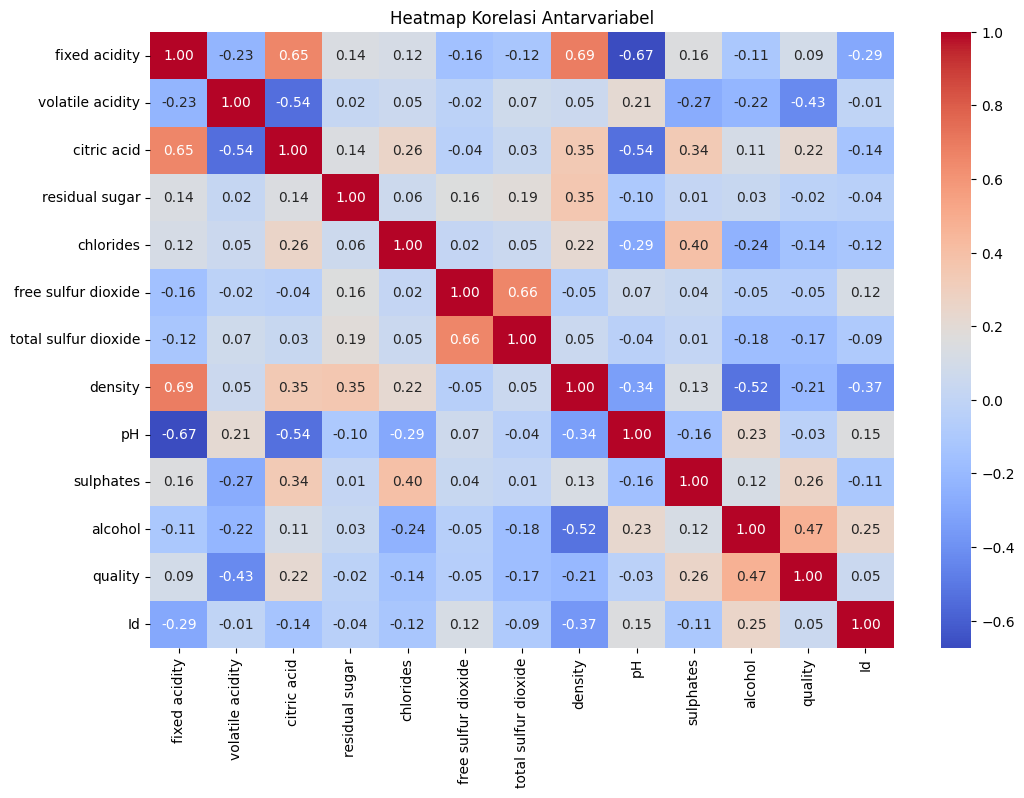

In [33]:
plt.figure(figsize=(12,8))
sns.heatmap(data_training.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antarvariabel')
plt.show()

### **Data Cleaning**

Tahap data cleaning dilakukan untuk membersihkan dataset dari data yang bermasalah.

Proses yang dilakukan:
1. Menghapus data duplikat.
2. Menangani missing value dengan fillna().
3. Memastikan data siap digunakan.

Tujuan:
1. Mengurangi kesalahan analisis.
2. Meningkatkan kualitas model machine learning.

In [34]:
train = data_training.copy()
train = train.fillna(train.mean(numeric_only=True))

### **Pisahkan Fitur dan Target**

Pada bagian ini dataset dipisahkan menjadi:

Fitur (X) → variabel input.
Target (y) → variabel yang akan diprediksi.

Contoh:
- Kolom quality dijadikan target.
- Kolom lainnya digunakan sebagai fitur.

Tujuan:
Menyiapkan data untuk proses training model.

In [35]:
x = train.drop(['quality','Id'], axis=1)
y = train['quality']

x_test_final=data_testing.drop(['Id'], axis=1)

### **Split Data**

Section ini digunakan untuk membagi dataset menjadi:
1. Data training.
2. Data validation/testing.

Pembagian dilakukan menggunakan train_test_split().

Tujuan:
1. Melatih model menggunakan data training.
2. Menguji performa model menggunakan data validation.

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42,  stratify=y
)

### **Scalling Data**

Tahap scaling dilakukan menggunakan StandardScaler() untuk menormalkan nilai fitur.

Tujuan:
1. Menyamakan skala antar fitur.
2. Membantu model machine learning bekerja lebih optimal.
3. Mengurangi pengaruh perbedaan rentang nilai data.

In [37]:
scaler = StandardScaler()

In [38]:
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
test_scaled = scaler.transform(x_test_final)

### **Random Forest**

Pada section ini digunakan algoritma Random Forest untuk melakukan klasifikasi data.

Langkah yang dilakukan:
1. Membuat model Random Forest.
2. Melatih model menggunakan data training.
3. Melakukan prediksi.
4. Menghitung akurasi model.
5. Menampilkan confusion matrix.

Tujuan:
Menentukan performa model klasifikasi menggunakan Random Forest.

Kelebihan:
- Akurasi tinggi.
- Mampu menangani data kompleks.
- Mengurangi overfitting.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print ("Akurasi Random Forest:", accuracy_score(y_val, y_pred))
print ("Classification Report:\n", classification_report(y_val, y_pred))

Akurasi Random Forest: 0.6453488372093024
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.82      0.75        73
           6       0.61      0.65      0.63        68
           7       0.50      0.27      0.35        22
           8       1.00      0.33      0.50         3

    accuracy                           0.65       172
   macro avg       0.47      0.35      0.37       172
weighted avg       0.62      0.65      0.62       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

akurasi_rf = accuracy_score(y_val, y_pred)

hasil_model = pd.DataFrame({
    'Model': ['Random Forest'],
    'Akurasi': [akurasi_rf]
})

print(hasil_model)

           Model   Akurasi
0  Random Forest  0.645349


In [41]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix Random Forest:")
print(cm)

Confusion Matrix Random Forest:
[[ 0  0  1  0  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 60 12  1  0]
 [ 0  0 21 44  3  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]


In [42]:
# This cell is now redundant as its content has been merged into GVhO6Mo7yL-N to ensure proper execution flow.

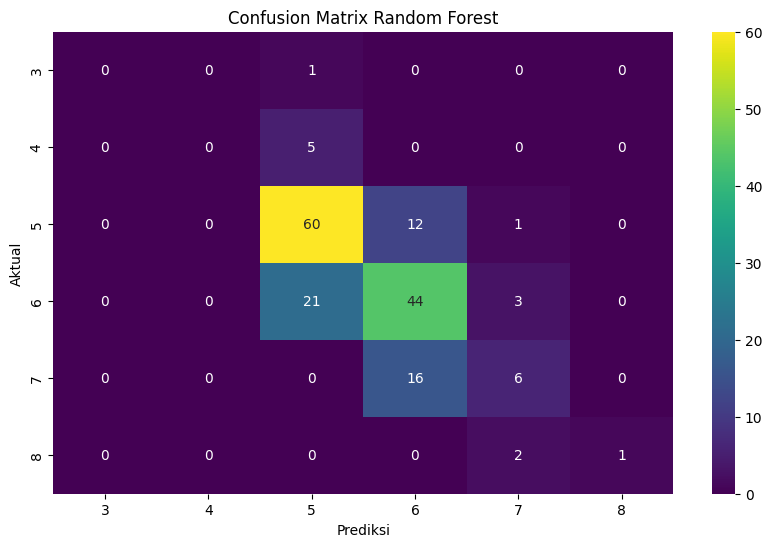

In [43]:
labels = sorted(y.unique())

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, cmap='viridis', fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Random Forest')
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.model_selection import train_test_split
train = data_training.copy()
train = train.fillna(train.mean(numeric_only=True))
x = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

x_test_final = data_testing.drop(['Id'], axis=1)

X_train_unscaled, _, _, _ = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
scaler.fit(X_train_unscaled)

test_scaled = scaler.transform(x_test_final)

model_terbaik = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_terbaik.fit(x, y)
prediksi_quality = model_terbaik.predict(test_scaled)
print(prediksi_quality)

[5 5 5 6 6 6 5 6 5 6 6 6 5 5 5 6 6 5 5 6 6 5 5 6 6 5 6 6 5 5 5 5 6 6 6 5 5
 6 6 6 6 6 6 5 5 5 5 6 5 5 6 5 5 6 5 6 5 6 6 5 6 5 6 6 6 5 5 5 5 6 6 5 6 5
 5 5 6 6 5 6 6 5 5 5 5 6 5 6 6 5 5 5 5 5 5 5 5 6 6 5 5 5 5 5 5 6 6 6 5 6 6
 6 6 6 5 5 5 5 6 6 5 5 6 6 5 5 5 5 5 6 5 5 6 6 7 5 5 6 5 5 6 5 6 5 5 5 6 5
 5 6 6 6 6 5 6 6 5 6 6 5 6 5 5 5 5 5 6 6 5 6 6 6 6 6 5 5 6 6 5 5 6 6 6 5 6
 5 6 5 6 6 5 6 6 6 5 6 5 6 6 5 5 5 6 5 6 5 5 6 6 6 5 6 6 5 6 5 6 5 6 6 5 6
 5 5 5 6 5 5 6 6 6 6 5 6 6 6 5 5 5 5 6 6 6 5 6 5 5 5 6 5 5 5 5 5 5 6 5 5 5
 5 5 6 6 5 5 5 6 6 5 6 5 6 6 5 5 6 5 5 6 6 5 6 6 5 5 6]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### **Decision Tree**

Section ini menggunakan algoritma Decision Tree untuk klasifikasi data.

Langkah:
1. Membuat model Decision Tree.
2. Training model.
3. Melakukan prediksi.
4. Menampilkan confusion matrix.

Tujuan:
Membandingkan performa model dengan algoritma lainnya.

Kelebihan:
- Mudah dipahami.
- Struktur model berbentuk pohon keputusan.

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_val)

print("Akurasi Decision Tree:", accuracy_score(y_val, y_pred_dt))
print(classification_report(y_val, y_pred_dt))

Akurasi Decision Tree: 0.5988372093023255
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.74      0.69        73
           6       0.61      0.54      0.57        68
           7       0.58      0.50      0.54        22
           8       0.50      0.33      0.40         3

    accuracy                           0.60       172
   macro avg       0.39      0.35      0.37       172
weighted avg       0.60      0.60      0.60       172



In [46]:
# Membuat confusion matrix dari hasil Decision Tree
cm_dt = confusion_matrix(y_val, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[ 0  0  1  0  0  0]
 [ 0  0  2  3  0  0]
 [ 2  2 54 13  2  0]
 [ 1  1 24 37  4  1]
 [ 0  1  2  8 11  0]
 [ 0  0  0  0  2  1]]


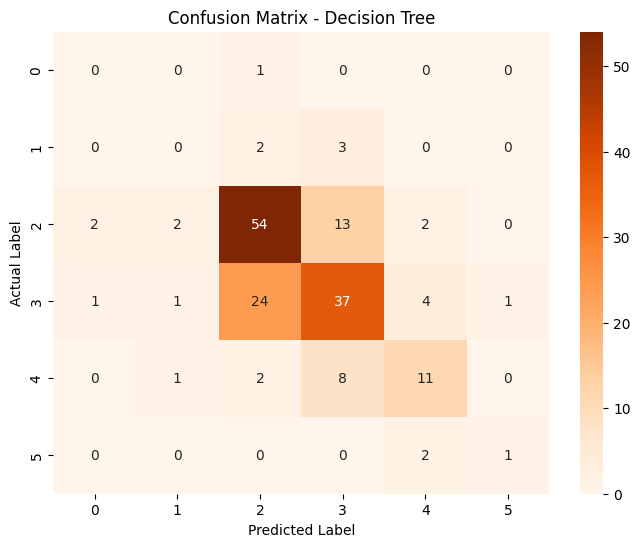

In [47]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - Decision Tree')

plt.show()

### **KNN**

Pada bagian ini digunakan algoritma KNN untuk melakukan klasifikasi berdasarkan tetangga terdekat.

Langkah:
1. Membuat model KNN.
2. Menentukan jumlah tetangga (k).
3. Melatih model.
4. Melakukan prediksi.
5. Menghitung akurasi.

Tujuan:
Membandingkan hasil klasifikasi dengan model lainnya.

In [48]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_val)

print("Akurasi KNN:", accuracy_score(y_val, y_pred_knn))
print(classification_report(y_val, y_pred_knn))

Akurasi KNN: 0.48255813953488375
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.54      0.59      0.56        73
           6       0.46      0.43      0.44        68
           7       0.48      0.50      0.49        22
           8       0.00      0.00      0.00         3

    accuracy                           0.48       172
   macro avg       0.25      0.25      0.25       172
weighted avg       0.47      0.48      0.48       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
cm_knn = confusion_matrix(y_val, y_pred_knn)

print("Confusion Matrix KNN:")
print(cm_knn)

Confusion Matrix KNN:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  5 43 24  1  0]
 [ 0  1 29 29  9  0]
 [ 0  0  3  8 11  0]
 [ 0  0  0  1  2  0]]


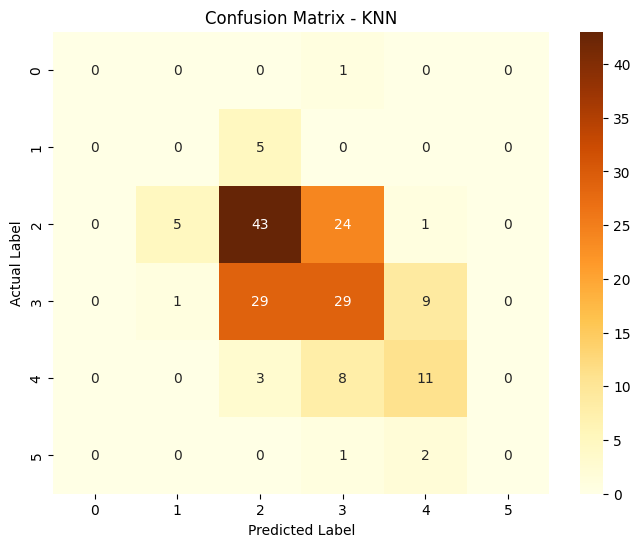

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlOrBr')

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - KNN')

plt.show()

In [51]:
from sklearn.metrics import accuracy_score
import pandas as pd

akurasi_rf = accuracy_score(y_val, y_pred)
akurasi_knn = accuracy_score(y_val, y_pred_knn)
akurasi_dt = accuracy_score(y_val, y_pred_dt)
hasil_model = pd.DataFrame({
    'model': ['Random Forest', 'KNN', 'Decision Tree'],
    'akurasi': [akurasi_rf, akurasi_knn, akurasi_dt]
})
hasil_model

,model,akurasi
0,Random Forest,0.645349
1,KNN,0.482558
2,Decision Tree,0.598837


Model terbaik adalah **model random forest**.

### **Evaluasi Model**

Pada section ini dilakukan perbandingan performa model berdasarkan nilai akurasi.

Model yang dibandingkan:
1. Random Forest.
2. Decision Tree.
3. KNN.

Hasil evaluasi menunjukkan bahwa model terbaik adalah Random Forest karena memiliki performa dan akurasi paling baik.

Tahap evaluasi dilakukan untuk mengukur performa model menggunakan:
1. Accuracy Score.
2. Confusion Matrix.
3. Classification Report.

Tujuan:
1. Mengetahui tingkat keberhasilan model.
2. Mengetahui kesalahan prediksi model.

In [52]:
hasil_prediksi = pd.DataFrame({
    'Id': data_testing['Id'],
    'quality': prediksi_quality
})
hasil_prediksi.head()

,Id,quality
0,222,5
1,1514,5
2,417,5
3,754,6
4,516,6


In [53]:
from google.colab import files
hasil_prediksi.to_csv('hasil_prediksi_quality.csv', index=False)
files.download('hasil_prediksi_quality.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Prediksi Data Testing**

Pada bagian ini model terbaik digunakan untuk memprediksi data testing.

Langkah:
1. Menggunakan model hasil training.
2. Melakukan prediksi pada dataset testing.
3. Menyimpan hasil prediksi.

Tujuan:
Mendapatkan hasil prediksi akhir.

In [54]:
# Redundant prediction; prediksi_quality is already computed.
# test_pred = model_terbaik.predict(test_scaled)

### **Hasil csv**

Hasil prediksi kemudian disimpan ke dalam file CSV.

Tujuan:
1. Mempermudah pengumpulan tugas.
2. Menyimpan hasil prediksi agar dapat digunakan kembali.

In [55]:
hasil = pd.DataFrame({
    'Id': data_testing['Id'],
    'quality': prediksi_quality
})

hasil.to_csv('hasilprediksi_3NIMterakhir.csv', index=False)

In [56]:
hasil["quality"].value_counts().sort_index()

,count
quality,
5,150
6,135
7,1
